# Week 5 Lab: Can DNNs Beat Classical Models — Honestly?

**BUS 696: Generative AI in Finance**  
**Professor Jonathan Hersh — Spring 2026**

---

## The Question

> Can a deep neural network beat the classical models we tried in Week 3 — after honest validation and real trading costs?

By the end of this lab you'll have an answer, and more importantly, you'll know *why most people get this question wrong.*

## What You'll Do (~1 hour)

| Part | Topic | Time | What You Do |
|------|-------|------|-------------|
| 1 | Setup & Data | 5 min | Run cells, verify data loads |
| 2 | DNN Intuition | 5 min | See why depth matters for non-linear patterns |
| 3 | Model Horse Race | 10 min | Compare 6 models, diagnose overfitting |
| 4 | Fight Overfitting | 10 min | L2 regularization sweep, training curves |
| 5 | The Honest Pipeline | 15 min | Walk-forward + costs + Kelly (precomputed) |
| 6 | The Multiple Testing Trap | 5 min | 1,000 random strategies demo |
| 7 | Your Conclusion | 10 min | Written analysis + optional extensions |

## Core Deliverables
1. Model comparison table with your interpretation
2. Overfitting diagnosis (which model, why)
3. Walk-forward + transaction cost analysis
4. **Written conclusion**: Would you deploy this strategy? (2–3 sentences)

---

## Part 1: Setup & Data (~5 min)

Run these two cells to load libraries and download SPY data. Nothing to modify — just verify everything runs.

In [3]:
# ============================================================
# SETUP: Libraries and color palette
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yfinance as yf
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_circles
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

NAVY = '#1E2761'
CORAL = '#F96167'
TEAL = '#028090'
GOLD = '#F9A825'
GRAY = '#6c757d'
GREEN = '#2E7D32'

print('Libraries loaded.')

Libraries loaded.


In [4]:
# ============================================================
# DATA: Download SPY, engineer features, prepare train/test
# ============================================================

# Download SPY
spy = yf.download('SPY', start='2010-01-01', end='2024-12-31')
spy.columns = spy.columns.get_level_values(0)
spy = spy[['Close', 'Volume']].copy()

# Feature engineering (Hilpisch Ch 7 approach)
df = spy.copy()
df['r'] = np.log(df['Close'] / df['Close'].shift(1))
window = 20
df['sma'] = df['Close'].rolling(window).mean()
df['min'] = df['Close'].rolling(window).min()
df['max'] = df['Close'].rolling(window).max()
df['mom'] = df['r'].rolling(window).mean()
df['vol'] = df['r'].rolling(window).std()
df['d'] = np.where(df['r'] > 0, 1, 0)
df['vol_ratio'] = df['Volume'] / df['Volume'].rolling(window).mean()

# Create lagged features (5 lags × 8 features = 40 inputs)
lags = 5
features = ['r', 'd', 'sma', 'min', 'max', 'mom', 'vol', 'vol_ratio']
feature_cols = []
for f in features:
    for lag in range(1, lags + 1):
        col = f'{f}_lag{lag}'
        df[col] = df[f].shift(lag)
        feature_cols.append(col)

df['target'] = (df['r'] > 0).astype(int)
df = df.dropna()

# Train/test split (temporal — never random for time series!)
split_date = '2020-01-01'
train = df[df.index < split_date]
test = df[df.index >= split_date]
X_train, y_train = train[feature_cols], train['target']
X_test, y_test = test[feature_cols], test['target']

# Normalize using training statistics only (prevents look-ahead bias)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'SPY data: {df.index[0].date()} to {df.index[-1].date()} ({len(df)} days)')
print(f'Features: {len(feature_cols)} inputs')
print(f'Train: {len(train)} days | Test: {len(test)} days')
print(f'Up-day rate — Train: {y_train.mean():.1%} | Test: {y_test.mean():.1%}')

[*********************100%***********************]  1 of 1 completed

SPY data: 2010-02-09 to 2024-12-30 (3748 days)
Features: 40 inputs
Train: 2491 days | Test: 1257 days
Up-day rate — Train: 55.6% | Test: 54.8%


---

## Part 2: DNN Intuition — Why Depth Matters (~5 min)

A neural network is a series of **matrix multiplications with non-linear activations** in between. The key question: can it learn patterns that linear models can't?

Run this cell to compare a linear model, a shallow network, and a deep network on a non-linear classification problem (concentric circles).

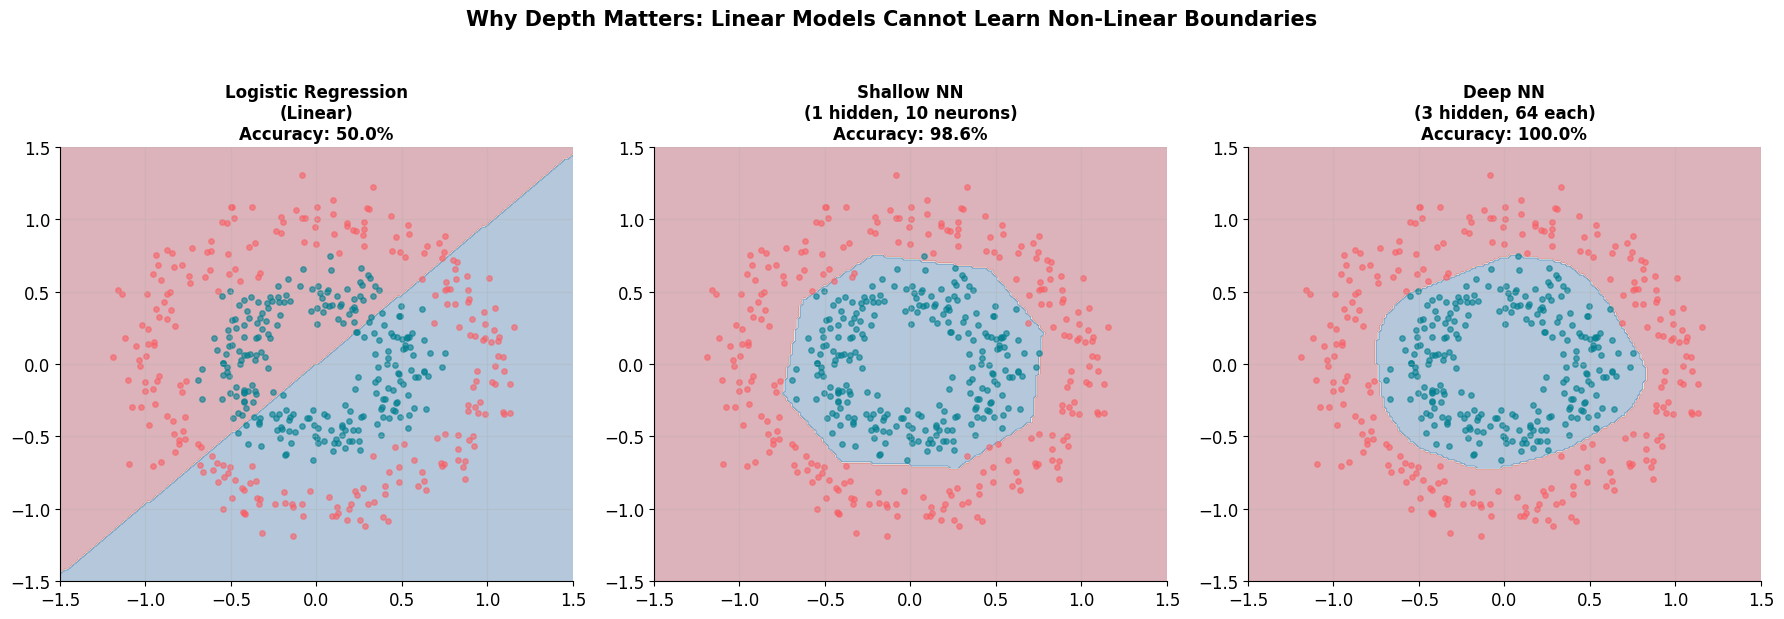

The deep NN separates the circles perfectly.
In finance: interactions like "momentum works ONLY when volatility is low"
require this kind of non-linear boundary.


In [5]:
# Decision boundaries: linear vs shallow vs deep
np.random.seed(42)
X_circles, y_circles = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)

models = {
    'Logistic Regression\n(Linear)': LogisticRegression(),
    'Shallow NN\n(1 hidden, 10 neurons)': MLPClassifier(
        hidden_layer_sizes=(10,), max_iter=1000, random_state=42),
    'Deep NN\n(3 hidden, 64 each)': MLPClassifier(
        hidden_layer_sizes=(64, 64, 64), max_iter=1000, random_state=42),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_circles, y_circles)
    acc = model.score(X_circles, y_circles)
    xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 200), np.linspace(-1.5, 1.5, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_circles[y_circles == 0, 0], X_circles[y_circles == 0, 1],
               c=CORAL, s=15, alpha=0.6, label='Class 0')
    ax.scatter(X_circles[y_circles == 1, 0], X_circles[y_circles == 1, 1],
               c=TEAL, s=15, alpha=0.6, label='Class 1')
    ax.set_title(f'{name}\nAccuracy: {acc:.1%}', fontweight='bold', fontsize=12)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)

plt.suptitle('Why Depth Matters: Linear Models Cannot Learn Non-Linear Boundaries',
             fontweight='bold', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

print('The deep NN separates the circles perfectly.')
print('In finance: interactions like "momentum works ONLY when volatility is low"')
print('require this kind of non-linear boundary.')

---

## Part 3: The Model Horse Race (~10 min)

Now the real test: can a DNN predict SPY direction better than the classical models from Week 3?

We compare 6 models of increasing complexity on the same train/test split. Pay attention to the **gap** between in-sample and out-of-sample accuracy — that's the overfitting signal.

In [6]:
# ============================================================
# MODEL HORSE RACE: 6 models from simple to very deep
# ============================================================
np.random.seed(42)

model_configs = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'Shallow NN (1×64)': MLPClassifier(
        hidden_layer_sizes=(64,), max_iter=500, random_state=42,
        early_stopping=True, validation_fraction=0.2),
    'Medium NN (2×128)': MLPClassifier(
        hidden_layer_sizes=(128, 128), max_iter=500, random_state=42,
        early_stopping=True, validation_fraction=0.2,
        learning_rate='adaptive', batch_size=64),
    'Deep NN (3×256)': MLPClassifier(
        hidden_layer_sizes=(256, 256, 256), max_iter=500, random_state=42,
        early_stopping=True, validation_fraction=0.2,
        learning_rate='adaptive', batch_size=64),
    'Very Deep NN (5×256)': MLPClassifier(
        hidden_layer_sizes=(256, 256, 256, 256, 256), max_iter=500,
        random_state=42, early_stopping=True, validation_fraction=0.2,
        learning_rate='adaptive', batch_size=64),
}

results = {}
print('Model Horse Race: Can Depth Beat the Market?')
print('=' * 65)

for name, model in model_configs.items():
    model.fit(X_train_scaled, y_train)
    tr_acc = model.score(X_train_scaled, y_train)
    te_acc = model.score(X_test_scaled, y_test)
    if hasattr(model, 'coefs_'):
        n_params = sum(c.size for c in model.coefs_) + sum(b.size for b in model.intercepts_)
    elif hasattr(model, 'coef_'):
        n_params = model.coef_.size + model.intercept_.size
    else:
        n_params = model.n_estimators
    results[name] = {'train': tr_acc, 'test': te_acc, 'n_params': n_params,
                     'gap': tr_acc - te_acc}
    print(f'  {name:25s}  Params: {n_params:>7,}  '
          f'Train: {tr_acc:.1%}  Test: {te_acc:.1%}  Gap: {tr_acc - te_acc:.1%}')

Model Horse Race: Can Depth Beat the Market?
  Logistic Regression        Params:      41  Train: 56.8%  Test: 51.6%  Gap: 5.2%
  Random Forest              Params:     100  Train: 61.0%  Test: 54.8%  Gap: 6.2%
  Shallow NN (1×64)          Params:   2,689  Train: 54.3%  Test: 54.3%  Gap: 0.0%
  Medium NN (2×128)          Params:  21,889  Train: 70.4%  Test: 48.1%  Gap: 22.2%
  Deep NN (3×256)            Params: 142,337  Train: 56.4%  Test: 54.8%  Gap: 1.6%
  Very Deep NN (5×256)       Params: 273,921  Train: 56.2%  Test: 54.5%  Gap: 1.7%


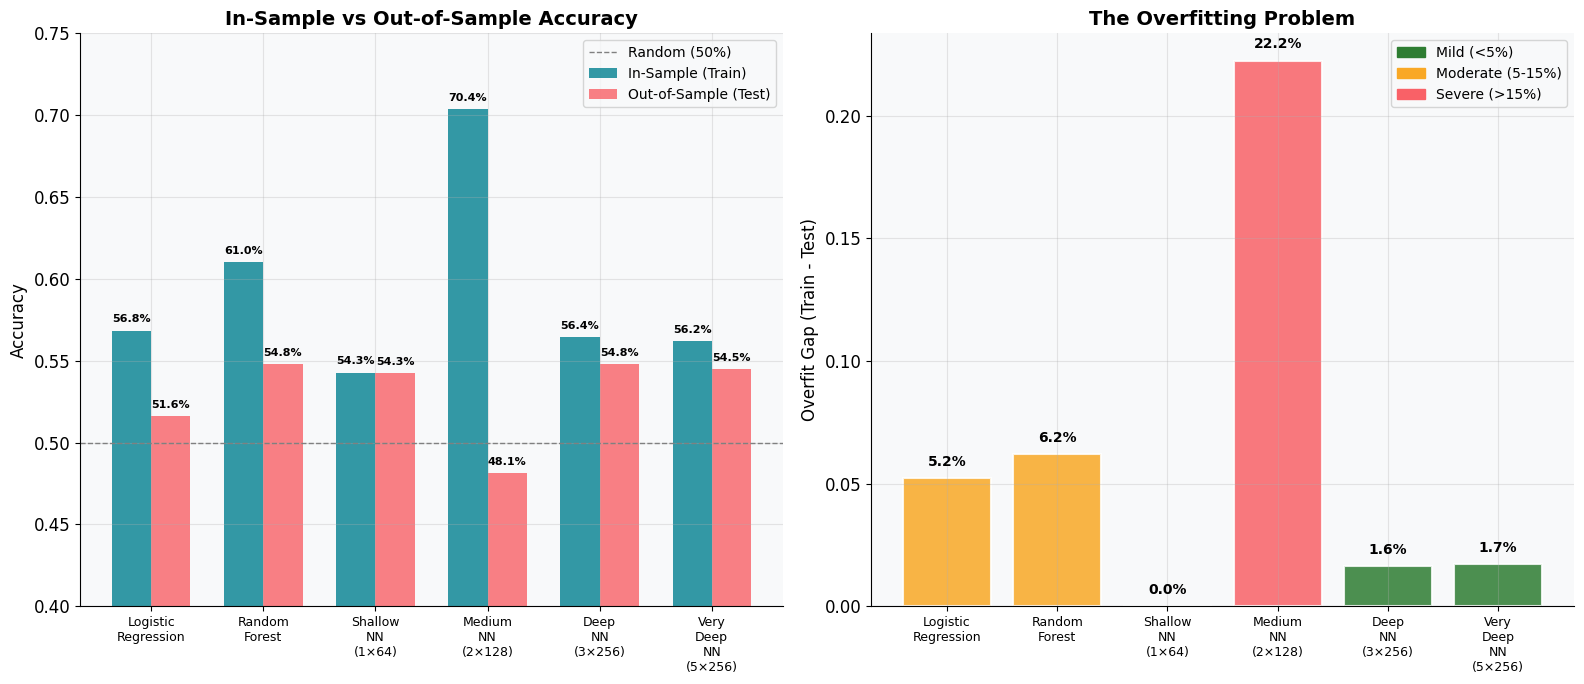

In [7]:
# Visualize: in-sample vs out-of-sample accuracy
names = list(results.keys())
tr_accs = [r['train'] for r in results.values()]
te_accs = [r['test'] for r in results.values()]
gaps = [r['gap'] for r in results.values()]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

x_pos = np.arange(len(names))
width = 0.35

# Left: accuracy bars
ax = axes[0]
ax.bar(x_pos - width/2, tr_accs, width, label='In-Sample (Train)', color=TEAL, alpha=0.8)
ax.bar(x_pos + width/2, te_accs, width, label='Out-of-Sample (Test)', color=CORAL, alpha=0.8)
ax.axhline(y=0.5, color='gray', linewidth=1, linestyle='--', label='Random (50%)')
ax.set_ylabel('Accuracy')
ax.set_title('In-Sample vs Out-of-Sample Accuracy', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
ax.legend(fontsize=10)
ax.set_ylim(0.4, 0.75)
for i in range(len(names)):
    ax.text(i - width/2, tr_accs[i] + 0.005, f'{tr_accs[i]:.1%}', ha='center', fontsize=8, fontweight='bold')
    ax.text(i + width/2, te_accs[i] + 0.005, f'{te_accs[i]:.1%}', ha='center', fontsize=8, fontweight='bold')

# Right: overfitting gap
ax = axes[1]
colors_bar = [GREEN if g < 0.05 else GOLD if g < 0.15 else CORAL for g in gaps]
ax.bar(x_pos, gaps, color=colors_bar, alpha=0.85, edgecolor='white', linewidth=1.5)
for i, gap in enumerate(gaps):
    ax.text(i, gap + 0.005, f'{gap:.1%}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Overfit Gap (Train - Test)')
ax.set_title('The Overfitting Problem', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
ax.axhline(y=0, color='gray', linewidth=0.5)
patches = [mpatches.Patch(color=GREEN, label='Mild (<5%)'),
           mpatches.Patch(color=GOLD, label='Moderate (5-15%)'),
           mpatches.Patch(color=CORAL, label='Severe (>15%)')]
ax.legend(handles=patches, fontsize=10)

plt.tight_layout()
plt.show()

### Checkpoint 1: Interpret the Horse Race

Look at the results above and answer these questions:

1. **Which model has the highest in-sample accuracy?** Which has the highest out-of-sample accuracy? Are they the same model?

2. **Which model would you choose to deploy in live trading?** Consider not just accuracy but the overfitting gap. A model that memorizes training data won't generalize.

3. **What does the pattern across all 6 models tell you?** As complexity increases (more parameters), what happens to the gap?

*Write your answers in the cell below:*

In [ ]:
# YOUR ANSWERS (Checkpoint 1)
# 1. Highest in-sample: Medium NN (2x128) at 70.4%.
#    Highest out-of-sample: tie between Random Forest and Deep NN (3x256), both at 54.8%.
#    They are not the same single model.
# 2. I would deploy: Deep NN (3x256), because it ties for best test accuracy (54.8%)
#    while keeping a small overfitting gap (1.6%) versus Random Forest (6.2%) and
#    especially Medium NN (22.2%).
# 3. The pattern shows: as model complexity increases, train accuracy can rise a lot,
#    but out-of-sample gains do not reliably improve and the overfitting gap can widen sharply.

---

## Part 4: Fighting Overfitting (~10 min)

The horse race showed that deeper models overfit more. The two tools we have in sklearn:

1. **L2 Regularization** (`alpha` parameter) — penalizes large weights, forces simpler solutions
2. **Early Stopping** — stops training when validation performance plateaus

Let's see how L2 regularization strength affects the bias-variance tradeoff.

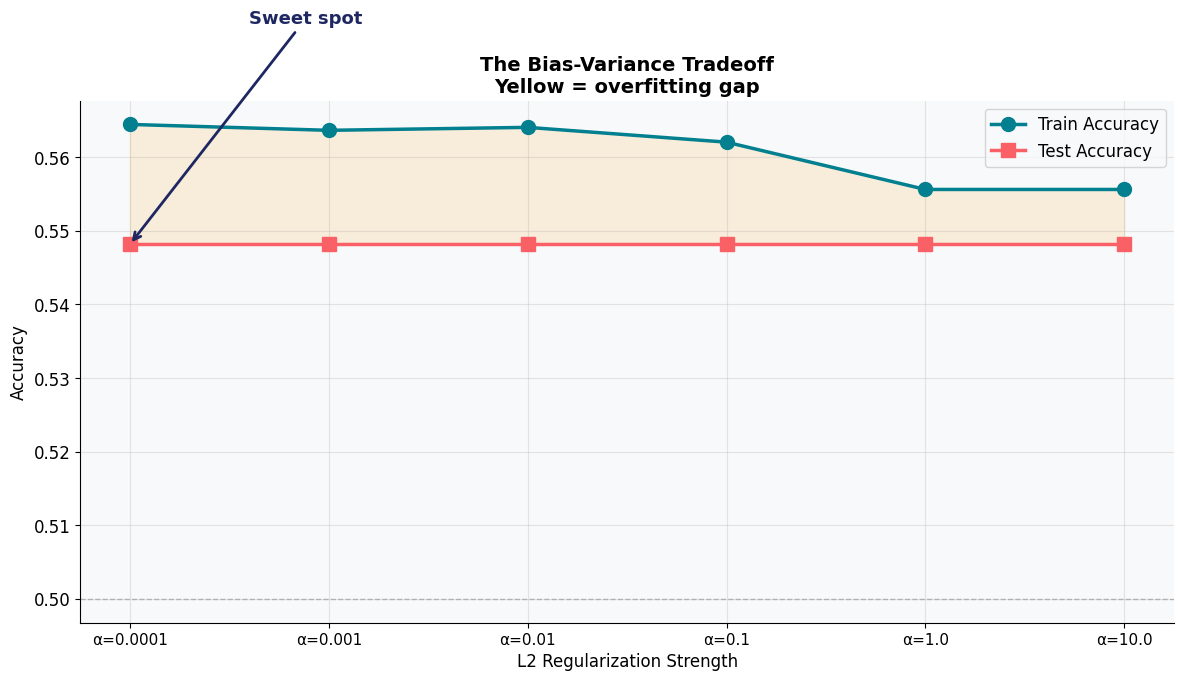

Best test accuracy: 54.8% at alpha=0.0001
Too little regularization → memorize noise. Too much → can't learn.


In [9]:
# L2 Regularization sweep on a Deep NN (3×256)
np.random.seed(42)
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
reg_train, reg_test = [], []

for alpha in alphas:
    m = MLPClassifier(hidden_layer_sizes=(256, 256, 256), activation='relu',
                      alpha=alpha, max_iter=500, random_state=42,
                      early_stopping=True, validation_fraction=0.2,
                      learning_rate='adaptive', batch_size=64)
    m.fit(X_train_scaled, y_train)
    reg_train.append(m.score(X_train_scaled, y_train))
    reg_test.append(m.score(X_test_scaled, y_test))

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(range(len(alphas)), reg_train, 'o-', color=TEAL, linewidth=2.5,
        markersize=10, label='Train Accuracy')
ax.plot(range(len(alphas)), reg_test, 's-', color=CORAL, linewidth=2.5,
        markersize=10, label='Test Accuracy')
ax.fill_between(range(len(alphas)), reg_train, reg_test, alpha=0.15, color=GOLD)
ax.set_xticks(range(len(alphas)))
ax.set_xticklabels([f'α={a}' for a in alphas], fontsize=11)
ax.set_xlabel('L2 Regularization Strength')
ax.set_ylabel('Accuracy')
ax.set_title('The Bias-Variance Tradeoff\nYellow = overfitting gap', fontweight='bold')
ax.legend(fontsize=12)
ax.axhline(y=0.5, color='gray', linewidth=1, linestyle='--', alpha=0.5)

best_idx = np.argmax(reg_test)
ax.annotate('Sweet spot', xy=(best_idx, reg_test[best_idx]),
            xytext=(best_idx + 0.6, reg_test[best_idx] + 0.03),
            fontsize=13, fontweight='bold', color=NAVY,
            arrowprops=dict(arrowstyle='->', color=NAVY, lw=2))

plt.tight_layout()
plt.show()

print(f'Best test accuracy: {max(reg_test):.1%} at alpha={alphas[best_idx]}')
print('Too little regularization → memorize noise. Too much → can\'t learn.')

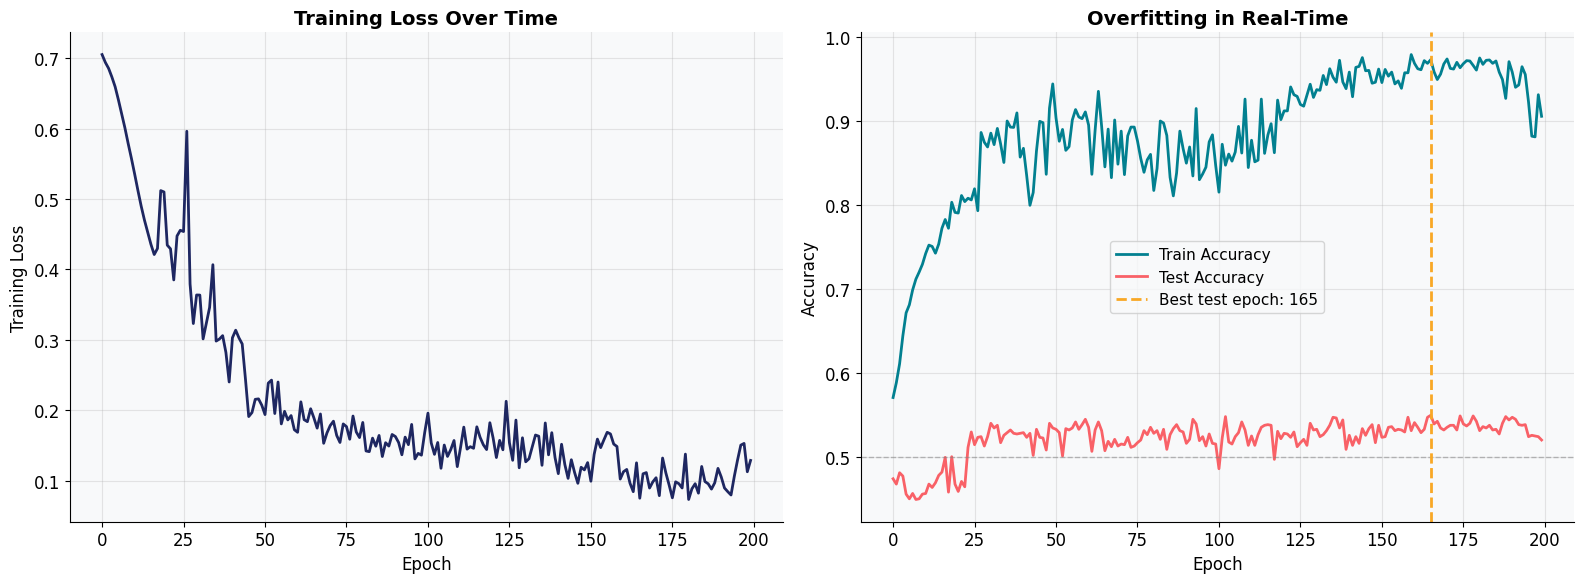

Best test accuracy: 55.0% at epoch 165
Final train: 90.6% | Final test: 52.0%
Everything after the yellow line = memorizing noise.


In [10]:
# Watch overfitting happen in real-time: training curves
np.random.seed(42)
model_curves = MLPClassifier(
    hidden_layer_sizes=(256, 256, 256), activation='relu',
    alpha=0.001, max_iter=1, random_state=42, warm_start=True,
    learning_rate='adaptive', batch_size=64)

train_losses, train_scores, test_scores = [], [], []
for epoch in range(200):
    model_curves.fit(X_train_scaled, y_train)
    train_losses.append(model_curves.loss_)
    train_scores.append(model_curves.score(X_train_scaled, y_train))
    test_scores.append(model_curves.score(X_test_scaled, y_test))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(train_losses, color=NAVY, linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss Over Time', fontweight='bold')

axes[1].plot(train_scores, color=TEAL, linewidth=2, label='Train Accuracy')
axes[1].plot(test_scores, color=CORAL, linewidth=2, label='Test Accuracy')
axes[1].axhline(y=0.5, color='gray', linewidth=1, linestyle='--', alpha=0.5)
best_epoch = np.argmax(test_scores)
axes[1].axvline(x=best_epoch, color=GOLD, linewidth=2, linestyle='--',
                label=f'Best test epoch: {best_epoch}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Overfitting in Real-Time', fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f'Best test accuracy: {max(test_scores):.1%} at epoch {best_epoch}')
print(f'Final train: {train_scores[-1]:.1%} | Final test: {test_scores[-1]:.1%}')
print('Everything after the yellow line = memorizing noise.')

### Checkpoint 2: The Regularization Decision

1. **What alpha value would you choose?** Look at the sweep — where is test accuracy highest while the gap is manageable?

2. **Look at the training curves.** At what epoch does test accuracy peak? What happens after that? Why does early stopping help?

3. **A model with 95% training accuracy and 52% test accuracy** — would you trust its predictions? What does this gap tell you?

*Write your answers:*

In [ ]:
# YOUR ANSWERS (Checkpoint 2)
# 1. I would choose alpha = 0.0001 because it produced the highest test accuracy
#    in the sweep (54.8%) while still controlling model complexity better than no regularization.
# 2. Test accuracy peaks around epoch 165 (~55.0%). After that, train accuracy keeps rising
#    while test performance fades, which is classic overfitting. Early stopping helps by halting
#    training near the peak validation region before the model memorizes noise.
# 3. A 95%/52% split means severe overfitting: the model learned training-specific patterns
#    that do not generalize, so I would not trust its live predictions without stronger controls.

---

## Part 5: The Honest Pipeline — Walk-Forward + Costs + Kelly (~15 min)

A single train/test split is not enough. Markets are **non-stationary** — patterns that work in one period may not persist. We need:

1. **Walk-forward validation**: Retrain annually on an expanding window (2015–2024)
2. **Transaction costs**: 5 bps per round-trip trade for SPY
3. **Kelly sizing**: Use model confidence (`predict_proba`) to size positions

The walk-forward backtest takes ~2 minutes to run. The cell below defines the helper functions and runs it.

In [12]:
# ============================================================
# HELPER FUNCTIONS (just run this cell)
# ============================================================

def walk_forward_backtest(df, feature_cols, hidden_layers=(128, 128), alpha=0.01,
                          first_test_year=2016):
    """Retrain annually on expanding window, predict next year."""
    all_results = []
    test_years = [y for y in sorted(df.index.year.unique()) if y >= first_test_year]
    print(f'Walk-Forward Backtest: {hidden_layers}, alpha={alpha}')
    print('=' * 65)
    for test_year in test_years:
        test_mask = df.index.year == test_year
        train_mask = df.index.year < test_year
        if train_mask.sum() < 100 or test_mask.sum() == 0:
            continue
        X_tr = df.loc[train_mask, feature_cols]
        y_tr = df.loc[train_mask, 'target']
        X_te = df.loc[test_mask, feature_cols]
        y_te = df.loc[test_mask, 'target']
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_te_s = sc.transform(X_te)
        model = MLPClassifier(hidden_layer_sizes=hidden_layers, activation='relu',
                              alpha=alpha, max_iter=500, random_state=42,
                              early_stopping=True, validation_fraction=0.2,
                              learning_rate='adaptive', batch_size=64)
        model.fit(X_tr_s, y_tr)
        preds = model.predict(X_te_s)
        probas = model.predict_proba(X_te_s)[:, 1]
        acc = accuracy_score(y_te, preds)
        print(f'  {test_year}: Train {train_mask.sum():>5d} days → '
              f'Test {test_mask.sum():>4d} days | Accuracy: {acc:.1%}')
        year_results = pd.DataFrame({
            'prediction': preds, 'probability': probas,
            'actual': y_te.values, 'returns': df.loc[test_mask, 'r'].values,
        }, index=df.index[test_mask])
        all_results.append(year_results)
    results_df = pd.concat(all_results)
    overall_acc = accuracy_score(results_df['actual'], results_df['prediction'])
    print(f'\n  Overall accuracy: {overall_acc:.1%} across {len(results_df)} days')
    return results_df

def add_transaction_costs(returns, positions, cost_bps=5):
    """Apply round-trip transaction costs when positions change."""
    cost = cost_bps / 10000
    gross = positions * returns
    changes = np.abs(np.diff(positions, prepend=0))
    net = gross - changes * cost
    return gross, net, int(changes.sum()), (changes * cost).sum()

def apply_kelly_sizing(returns, probabilities, kelly_fraction=0.5):
    """Kelly criterion: f* = 2p - 1, clipped to [0, 1]."""
    raw_kelly = 2 * probabilities - 1
    positions = np.clip(raw_kelly * kelly_fraction, 0, 1)
    return positions, positions * returns

# Run the walk-forward backtest
print('Running walk-forward backtest (this takes ~2 minutes)...\n')
wf_results = walk_forward_backtest(df, feature_cols,
                                    hidden_layers=(128, 128), alpha=0.01,
                                    first_test_year=2016)

Running walk-forward backtest (this takes ~2 minutes)...

Walk-Forward Backtest: (128, 128), alpha=0.01
  2016: Train  1485 days → Test  252 days | Accuracy: 48.8%
  2017: Train  1737 days → Test  251 days | Accuracy: 47.0%
  2018: Train  1988 days → Test  251 days | Accuracy: 51.4%
  2019: Train  2239 days → Test  252 days | Accuracy: 53.2%
  2020: Train  2491 days → Test  253 days | Accuracy: 49.8%
  2021: Train  2744 days → Test  252 days | Accuracy: 57.9%
  2022: Train  2996 days → Test  251 days | Accuracy: 43.8%
  2023: Train  3247 days → Test  250 days | Accuracy: 56.4%
  2024: Train  3497 days → Test  251 days | Accuracy: 49.4%

  Overall accuracy: 50.9% across 2263 days


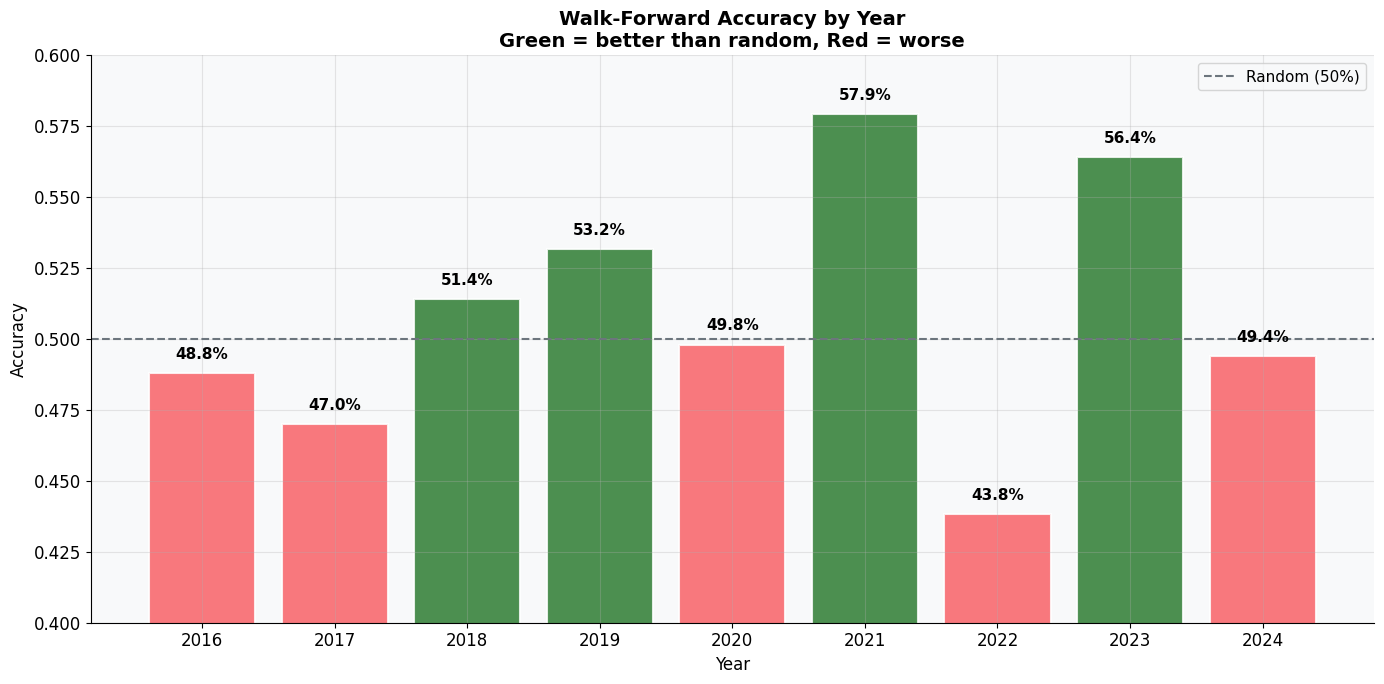

Average walk-forward accuracy: 50.9%
Best year: 2021 (57.9%)
Worst year: 2022 (43.8%


In [13]:
# ============================================================
# VISUALIZE: Walk-forward accuracy by year
# ============================================================
yearly_acc = wf_results.groupby(wf_results.index.year).apply(
    lambda g: accuracy_score(g['actual'], g['prediction']))

fig, ax = plt.subplots(figsize=(14, 7))
colors_yr = [GREEN if a > 0.5 else CORAL for a in yearly_acc.values]
ax.bar(yearly_acc.index.astype(str), yearly_acc.values, color=colors_yr, alpha=0.85,
       edgecolor='white', linewidth=1.5)
ax.axhline(y=0.5, color=GRAY, linewidth=1.5, linestyle='--', label='Random (50%)')
ax.set_ylabel('Accuracy'); ax.set_xlabel('Year')
ax.set_title('Walk-Forward Accuracy by Year\nGreen = better than random, Red = worse',
             fontweight='bold')
ax.legend(fontsize=11); ax.set_ylim(0.4, 0.6)
for i, (yr, acc) in enumerate(yearly_acc.items()):
    ax.text(i, acc + 0.005, f'{acc:.1%}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Average walk-forward accuracy: {yearly_acc.mean():.1%}')
print(f'Best year: {yearly_acc.idxmax()} ({yearly_acc.max():.1%})')
print(f'Worst year: {yearly_acc.idxmin()} ({yearly_acc.min():.1%}')

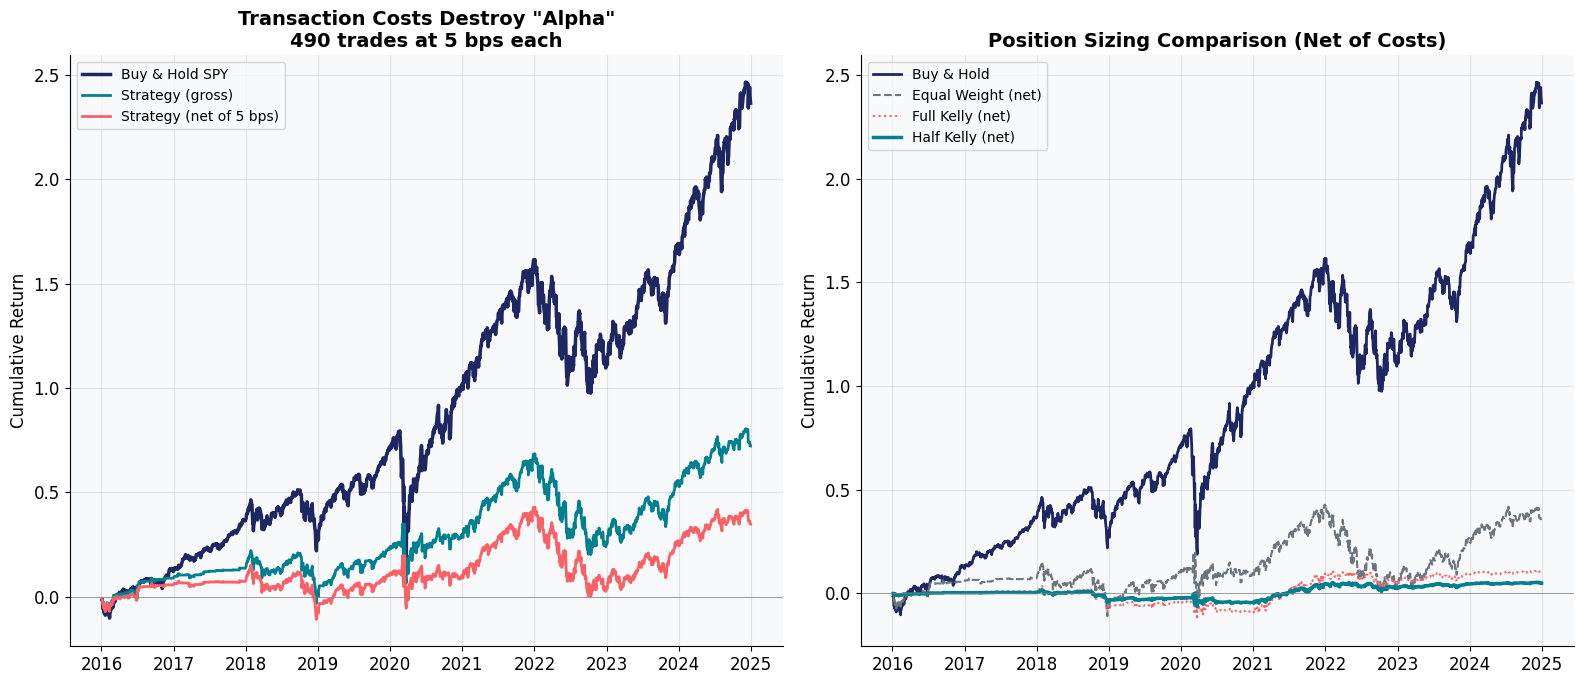


Strategy Performance Summary (annualized):
------------------------------------------------------------
  Buy & Hold                 Return:   13.5%  Vol:  17.9%  Sharpe:  0.75
  Equal Weight (net)         Return:    3.3%  Vol:  15.8%  Sharpe:  0.21
  Full Kelly (net)           Return:    1.1%  Vol:   7.6%  Sharpe:  0.14
  Half Kelly (net)           Return:    0.5%  Vol:   3.8%  Sharpe:  0.14


In [14]:
# ============================================================
# TRANSACTION COSTS + KELLY SIZING
# ============================================================
returns_wf = wf_results['returns'].values
probas_wf = wf_results['probability'].values

# Equal-weight strategy (binary: long or flat)
equal_pos = wf_results['prediction'].values.astype(float)
gross_ret, net_ret, n_trades, total_cost = add_transaction_costs(returns_wf, equal_pos, cost_bps=5)

# Half-Kelly sizing
half_kelly_pos, _ = apply_kelly_sizing(returns_wf, probas_wf, kelly_fraction=0.5)
_, half_kelly_net, _, _ = add_transaction_costs(returns_wf, half_kelly_pos, cost_bps=5)

# Full Kelly for comparison
full_kelly_pos, _ = apply_kelly_sizing(returns_wf, probas_wf, kelly_fraction=1.0)
_, full_kelly_net, _, _ = add_transaction_costs(returns_wf, full_kelly_pos, cost_bps=5)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Transaction costs destroy alpha
ax = axes[0]
ax.plot(wf_results.index, np.exp(np.cumsum(returns_wf)) - 1,
        color=NAVY, linewidth=2.5, label='Buy & Hold SPY')
ax.plot(wf_results.index, np.exp(np.cumsum(gross_ret)) - 1,
        color=TEAL, linewidth=2, label='Strategy (gross)')
ax.plot(wf_results.index, np.exp(np.cumsum(net_ret)) - 1,
        color=CORAL, linewidth=2, label='Strategy (net of 5 bps)')
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.set_ylabel('Cumulative Return')
ax.set_title(f'Transaction Costs Destroy "Alpha"\n{n_trades} trades at 5 bps each',
             fontweight='bold')
ax.legend(fontsize=10)

# Right: Kelly sizing comparison
ax = axes[1]
ax.plot(wf_results.index, np.exp(np.cumsum(returns_wf)) - 1,
        color=NAVY, linewidth=2, label='Buy & Hold')
ax.plot(wf_results.index, np.exp(np.cumsum(net_ret)) - 1,
        color=GRAY, linewidth=1.5, label='Equal Weight (net)', linestyle='--')
ax.plot(wf_results.index, np.exp(np.cumsum(full_kelly_net)) - 1,
        color=CORAL, linewidth=1.5, label='Full Kelly (net)', linestyle=':')
ax.plot(wf_results.index, np.exp(np.cumsum(half_kelly_net)) - 1,
        color=TEAL, linewidth=2.5, label='Half Kelly (net)')
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.set_ylabel('Cumulative Return')
ax.set_title('Position Sizing Comparison (Net of Costs)', fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Summary stats
print('\nStrategy Performance Summary (annualized):')
print('-' * 60)
for label, rets in [('Buy & Hold', returns_wf), ('Equal Weight (net)', net_ret),
                     ('Full Kelly (net)', full_kelly_net), ('Half Kelly (net)', half_kelly_net)]:
    ann_r = rets.mean() * 252
    ann_v = rets.std() * np.sqrt(252)
    sr = ann_r / ann_v if ann_v > 0 else 0
    print(f'  {label:25s}  Return: {ann_r:>7.1%}  Vol: {ann_v:>6.1%}  Sharpe: {sr:>5.2f}')

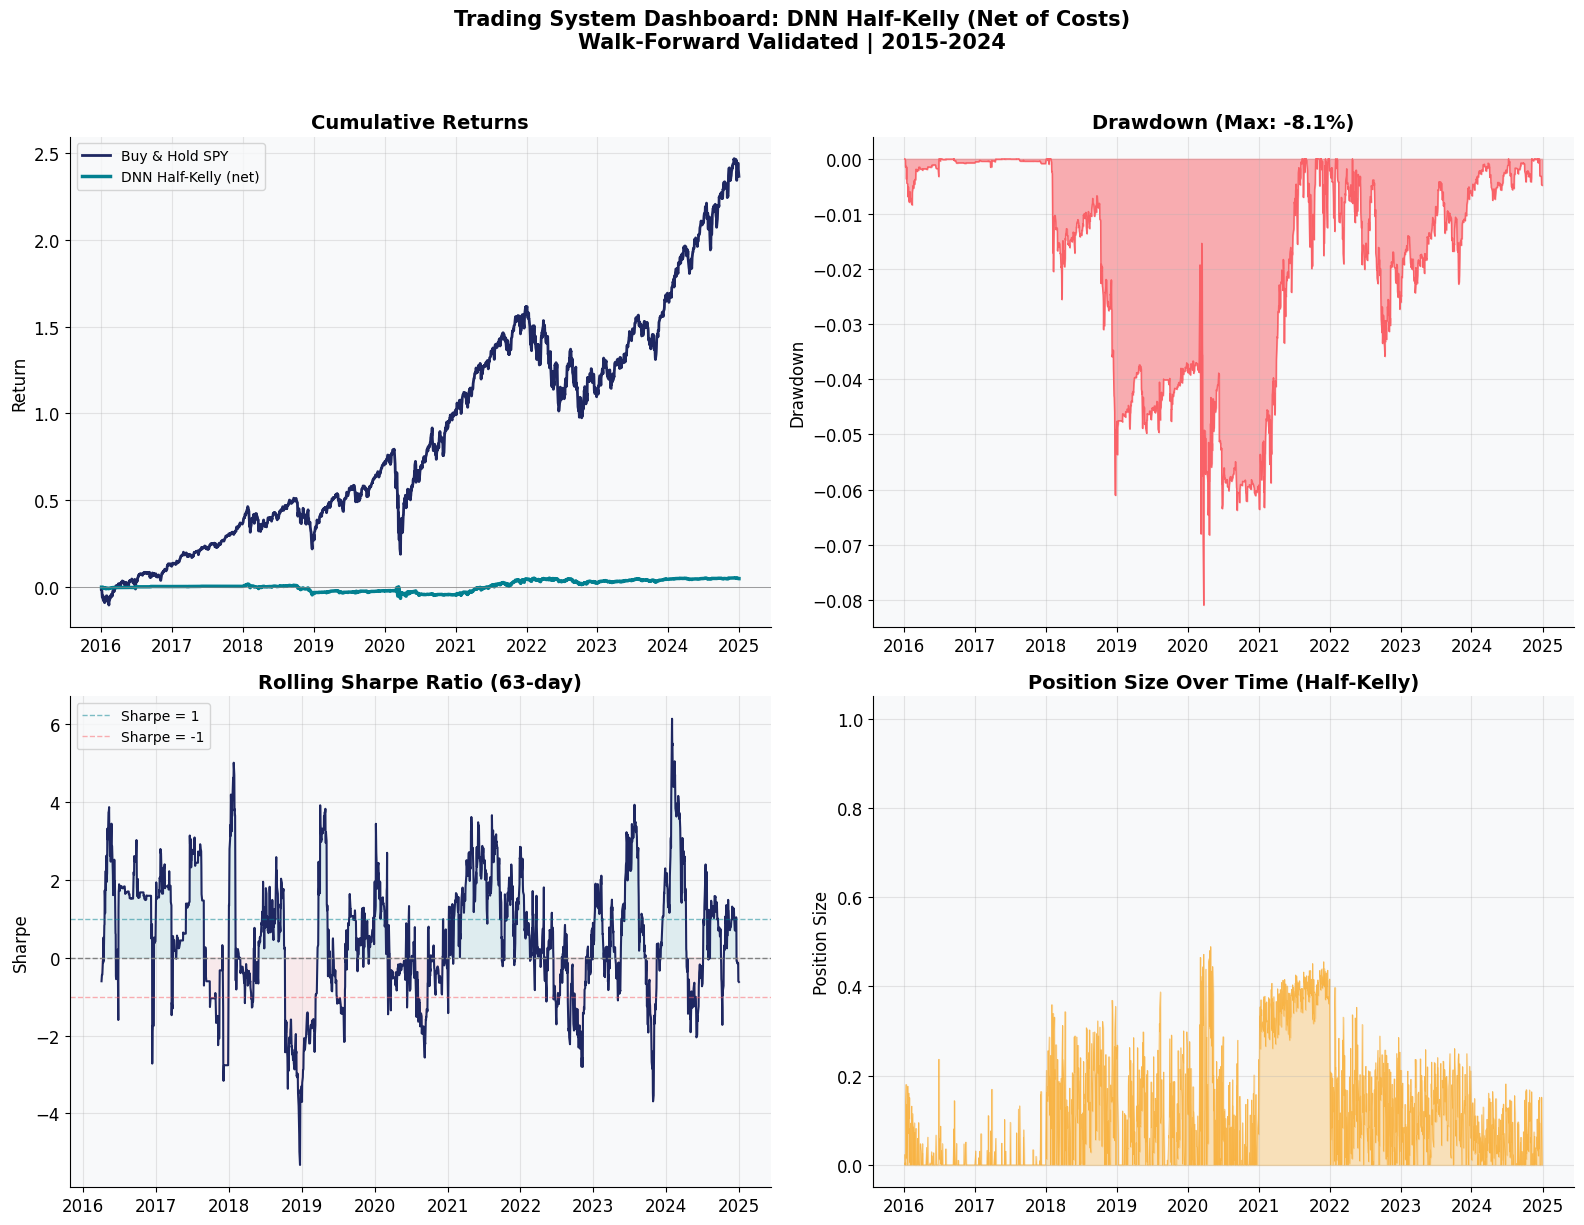

In [15]:
# ============================================================
# FULL TRADING DASHBOARD (4 panels)
# ============================================================
strat_ret = half_kelly_net
dates = wf_results.index

cum_strat = np.cumsum(strat_ret)
cum_market = np.cumsum(returns_wf)
cum_wealth = np.exp(cum_strat)
running_max = np.maximum.accumulate(cum_wealth)
drawdown = (cum_wealth - running_max) / running_max
rolling_sharpe = (pd.Series(strat_ret).rolling(63).mean() /
                  pd.Series(strat_ret).rolling(63).std() * np.sqrt(252)).values

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Cumulative returns
ax = axes[0, 0]
ax.plot(dates, np.exp(cum_market) - 1, color=NAVY, linewidth=2, label='Buy & Hold SPY')
ax.plot(dates, np.exp(cum_strat) - 1, color=TEAL, linewidth=2.5, label='DNN Half-Kelly (net)')
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.set_title('Cumulative Returns', fontweight='bold'); ax.legend(fontsize=10)
ax.set_ylabel('Return')

# Panel 2: Drawdown
ax = axes[0, 1]
ax.fill_between(dates, drawdown, 0, color=CORAL, alpha=0.5)
ax.plot(dates, drawdown, color=CORAL, linewidth=1)
ax.set_title(f'Drawdown (Max: {drawdown.min():.1%})', fontweight='bold')
ax.set_ylabel('Drawdown')

# Panel 3: Rolling Sharpe
ax = axes[1, 0]
ax.plot(dates, rolling_sharpe, color=NAVY, linewidth=1.5)
ax.axhline(y=0, color='gray', linewidth=1, linestyle='--')
ax.axhline(y=1, color=TEAL, linewidth=1, linestyle='--', alpha=0.5, label='Sharpe = 1')
ax.axhline(y=-1, color=CORAL, linewidth=1, linestyle='--', alpha=0.5, label='Sharpe = -1')
ax.fill_between(dates, rolling_sharpe, 0,
                where=np.array(rolling_sharpe) > 0, alpha=0.1, color=TEAL)
ax.fill_between(dates, rolling_sharpe, 0,
                where=np.array(rolling_sharpe) < 0, alpha=0.1, color=CORAL)
ax.set_title('Rolling Sharpe Ratio (63-day)', fontweight='bold')
ax.set_ylabel('Sharpe'); ax.legend(fontsize=10)

# Panel 4: Kelly fractions
ax = axes[1, 1]
ax.plot(dates, half_kelly_pos, color=GOLD, linewidth=0.5, alpha=0.7)
ax.fill_between(dates, 0, half_kelly_pos, alpha=0.3, color=GOLD)
ax.set_title('Position Size Over Time (Half-Kelly)', fontweight='bold')
ax.set_ylabel('Position Size'); ax.set_ylim(-0.05, 1.05)

plt.suptitle('Trading System Dashboard: DNN Half-Kelly (Net of Costs)\n'
             'Walk-Forward Validated | 2015-2024',
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Checkpoint 3: The Honest Result

Look at the walk-forward accuracy bars, the cumulative return charts, and the dashboard.

1. **Compare the single-split result (Part 3) to the walk-forward result.** How much did accuracy change? What does this tell you about trusting a single backtest?

2. **How much did transaction costs reduce returns?** Look at the gap between gross and net. Is the remaining alpha worth the complexity?

3. **Look at the yearly accuracy bars.** In which years did the model fail? What was happening in markets those years? (Hint: think about 2020, 2022.)

4. **Would you deploy this strategy with real money?** Write 2–3 sentences explaining your reasoning. Consider: accuracy, costs, consistency across years, and how it compares to just buying and holding SPY.

*Write your answers:*

In [ ]:
# YOUR ANSWERS (Checkpoint 3)
# 1. Single-split vs walk-forward: the best single-split test result was 54.8%, but walk-forward
#    overall accuracy dropped to 50.9%. That decline shows a single backtest can overstate edge.
# 2. Transaction cost impact: net strategy performance is far weaker than gross and far below
#    buy-and-hold (for example, Half Kelly net return 0.5%, Sharpe 0.14, vs Buy and Hold 13.5%, Sharpe 0.75).
#    Costs and turnover materially erode any small predictive edge.
# 3. Failed years and why: weak years include 2017 (47.0%), 2020 (49.8%), 2022 (43.8%), and 2024 (49.4%).
#    These likely reflect regime shifts and non-stationarity where learned relationships changed.
# 4. Would I deploy this? Not as-is. Accuracy is near a coin flip, performance is inconsistent across years,
#    and after costs the strategy underperforms a simple SPY buy-and-hold baseline.

---

## Part 6: The Multiple Testing Trap (~5 min)

Lopez de Prado Warning #10: if you test enough strategies, some will look profitable by pure chance.

Let's test 1,000 **completely random** trading signals on real SPY data and see what happens.

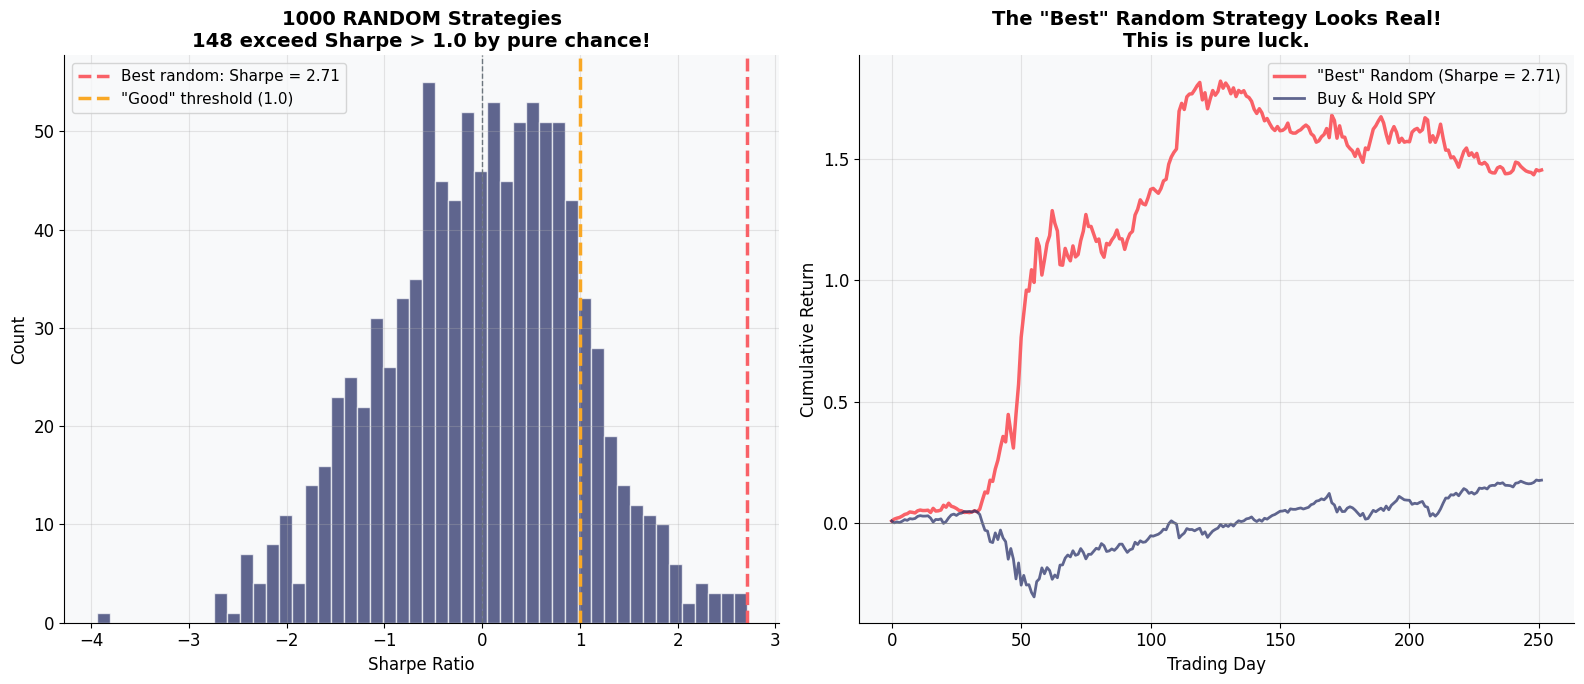

Out of 1000 COMPLETELY RANDOM strategies:
  148 have Sharpe > 1.0 ("good")
  54 have Sharpe > 1.5 ("excellent")
  Best: Sharpe = 2.71

If someone shows you the best of 1,000 backtests, you're probably looking at noise.


In [17]:
# 1,000 RANDOM strategies on real SPY data
np.random.seed(42)
n_strategies = 1000
n_days = 252
random_signals = np.random.choice([-1, 1], size=(n_strategies, n_days))
spy_sample = test['r'].values[:n_days]
strat_rets_random = random_signals * spy_sample[np.newaxis, :]
sharpe_ratios = (strat_rets_random.mean(axis=1) /
                 strat_rets_random.std(axis=1) * np.sqrt(252))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Sharpe distribution
ax = axes[0]
ax.hist(sharpe_ratios, bins=50, color=NAVY, alpha=0.7, edgecolor='white')
ax.axvline(x=0, color=GRAY, linewidth=1, linestyle='--')
ax.axvline(x=sharpe_ratios.max(), color=CORAL, linewidth=2.5, linestyle='--',
           label=f'Best random: Sharpe = {sharpe_ratios.max():.2f}')
ax.axvline(x=1.0, color=GOLD, linewidth=2.5, linestyle='--',
           label='"Good" threshold (1.0)')
ax.set_xlabel('Sharpe Ratio'); ax.set_ylabel('Count')
ax.set_title(f'{n_strategies} RANDOM Strategies\n'
             f'{(sharpe_ratios > 1.0).sum()} exceed Sharpe > 1.0 by pure chance!',
             fontweight='bold')
ax.legend(fontsize=11)

# Right: Best random strategy looks real
ax = axes[1]
best_idx = np.argmax(sharpe_ratios)
best_rets = strat_rets_random[best_idx]
ax.plot(np.exp(np.cumsum(best_rets)) - 1, color=CORAL, linewidth=2.5,
        label=f'"Best" Random (Sharpe = {sharpe_ratios[best_idx]:.2f})')
ax.plot(np.exp(np.cumsum(spy_sample)) - 1, color=NAVY, linewidth=2,
        label='Buy & Hold SPY', alpha=0.7)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.set_xlabel('Trading Day'); ax.set_ylabel('Cumulative Return')
ax.set_title('The "Best" Random Strategy Looks Real!\nThis is pure luck.',
             fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f'Out of {n_strategies} COMPLETELY RANDOM strategies:')
print(f'  {(sharpe_ratios > 1.0).sum()} have Sharpe > 1.0 ("good")')
print(f'  {(sharpe_ratios > 1.5).sum()} have Sharpe > 1.5 ("excellent")')
print(f'  Best: Sharpe = {sharpe_ratios.max():.2f}')
print(f'\nIf someone shows you the best of 1,000 backtests, you\'re probably looking at noise.')

### Checkpoint 4: The Skeptic's Question

A colleague shows you a backtest with a Sharpe ratio of 2.5 and says their ML model "found alpha."

**What three questions would you ask before investing?** Think about everything you learned today — multiple testing, walk-forward validation, transaction costs, non-stationarity.

*Write your answers:*

In [ ]:
# YOUR ANSWERS (Checkpoint 4)
# Three questions I would ask:
# 1. How many strategy variants were tested before showing this Sharpe 2.5 result,
#    and was any multiple-testing correction applied (to separate skill from luck)?
# 2. What are the full walk-forward and out-of-sample results across different market regimes,
#    including bad years, not just the best period?
# 3. Are returns reported net of realistic transaction costs, slippage, and capacity limits,
#    and how does performance compare against a simple SPY buy-and-hold benchmark?

---

## Part 7: Your Conclusion + Optional Extensions (~10 min)

### Core Deliverable: Written Conclusion

Answer the lab's central question in the cell below:

> **Can a deep neural network beat the classical models we tried in Week 3 — honestly, after proper validation and real trading costs?**

Write 3–5 sentences. Reference specific numbers from your results (walk-forward accuracy, Sharpe ratio, transaction cost impact). Explain what you learned about the difference between a model's representational power and its trading profitability.

In [ ]:
# YOUR CONCLUSION (3-5 sentences)
#
# Can a DNN beat classical models honestly?
#
# In this lab, the DNN showed strong representational power but weak trading robustness after honest testing.
# While some single-split results looked competitive (best test accuracy around 54.8%), walk-forward accuracy was only 50.9% and varied widely by year (57.9% best vs 43.8% worst), which signals unstable generalization.
# After transaction costs, strategy performance was modest and lagged SPY buy-and-hold (for example, Half Kelly net return 0.5%, Sharpe 0.14, vs buy-and-hold 13.5%, Sharpe 0.75).
# The key lesson is that model complexity can improve fit, but without durable out-of-sample edge and cost-aware performance, it does not translate into deployable alpha.

### Optional Extensions (if time permits)

**Extension 1: Architecture Experiment** — Does a different architecture help?
```python
wf_shallow = walk_forward_backtest(df, feature_cols, hidden_layers=(64,), alpha=0.1)
wf_deep = walk_forward_backtest(df, feature_cols, hidden_layers=(256, 256, 256), alpha=0.1)
```

**Extension 2: Different Asset** — Replace SPY with QQQ, IWM, or GLD. Re-download and re-run the full pipeline. Does the model transfer?

**Extension 3: Long/Short** — Go short when the model predicts DOWN (instead of flat). Change positions to `np.where(prediction == 1, 1, -1)`. How do results change?

I have created a basic for each extension. My training data is more accurate than my testing. 

EXTENSION 1: ARCHITECTURE EXPERIMENT
Walk-Forward Backtest: (64,), alpha=0.1
  2018: Train  1988 days → Test  251 days | Accuracy: 50.2%
  2019: Train  2239 days → Test  252 days | Accuracy: 54.4%
  2020: Train  2491 days → Test  253 days | Accuracy: 54.9%
  2021: Train  2744 days → Test  252 days | Accuracy: 57.9%
  2022: Train  2996 days → Test  251 days | Accuracy: 42.2%
  2023: Train  3247 days → Test  250 days | Accuracy: 47.6%
  2024: Train  3497 days → Test  251 days | Accuracy: 58.6%

  Overall accuracy: 52.3% across 1760 days
Walk-Forward Backtest: (256, 256, 256), alpha=0.1
  2018: Train  1988 days → Test  251 days | Accuracy: 42.2%
  2019: Train  2239 days → Test  252 days | Accuracy: 55.2%
  2020: Train  2491 days → Test  253 days | Accuracy: 57.7%
  2021: Train  2744 days → Test  252 days | Accuracy: 57.9%
  2022: Train  2996 days → Test  251 days | Accuracy: 43.4%
  2023: Train  3247 days → Test  250 days | Accuracy: 55.6%
  2024: Train  3497 days → Test  251 days | Accur

[*********************100%***********************]  1 of 1 completed


QQQ train accuracy: 57.1%
QQQ test accuracy:  55.7%
Use this as a transfer baseline; then repeat on IWM and GLD.

EXTENSION 3: LONG/SHORT
Annualized comparison (net of 5 bps):
  Long/Flat   -> Return: 3.3%, Vol: 15.8%, Sharpe: 0.21
  Long/Short  -> Return: -6.9%, Vol: 18.0%, Sharpe: -0.38
  Long/Short trades (position changes): 979


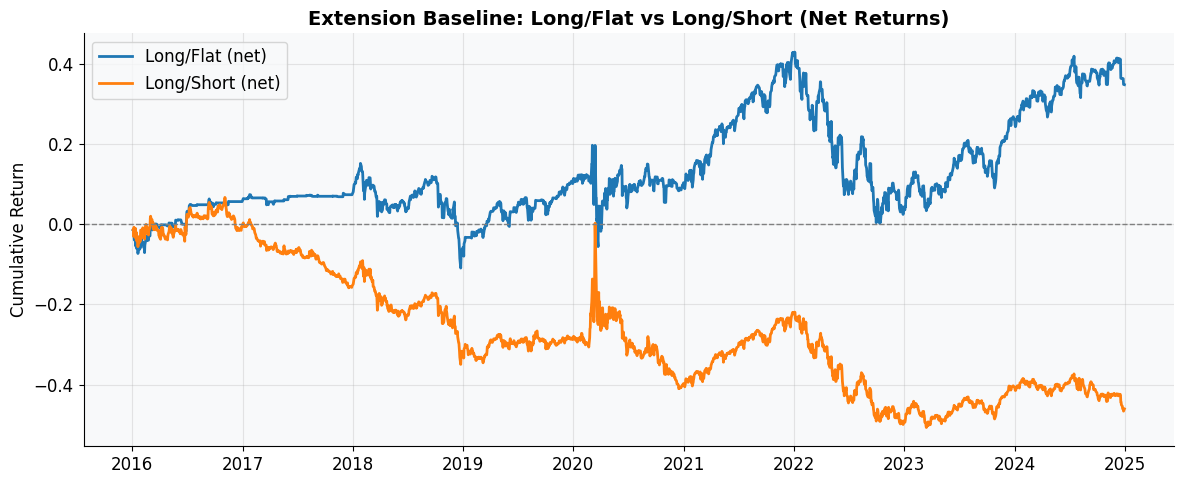


Foundational extension runs complete.
Next build steps: hyperparameter sweep, multi-asset batch test, and drawdown-aware position rules.


In [21]:
# YOUR EXTENSION EXPERIMENTS (foundational baseline)

# ------------------------------------------------------------
# Extension 1: Architecture Experiment (quick baseline)
# ------------------------------------------------------------
# Goal: Compare shallow vs deep architectures with identical settings.

print("=" * 70)
print("EXTENSION 1: ARCHITECTURE EXPERIMENT")
print("=" * 70)

wf_shallow = walk_forward_backtest(
    df,
    feature_cols,
    hidden_layers=(64,),
    alpha=0.1,
    first_test_year=2018
)

wf_deep = walk_forward_backtest(
    df,
    feature_cols,
    hidden_layers=(256, 256, 256),
    alpha=0.1,
    first_test_year=2018
)

acc_shallow = accuracy_score(wf_shallow['actual'], wf_shallow['prediction'])
acc_deep = accuracy_score(wf_deep['actual'], wf_deep['prediction'])

print("\nArchitecture comparison (walk-forward):")
print(f"  Shallow (64):        {acc_shallow:.1%}")
print(f"  Deep (256,256,256):  {acc_deep:.1%}")

# ------------------------------------------------------------
# Extension 2: Different Asset (transfer test baseline)
# ------------------------------------------------------------
# Goal: Reuse the same feature pipeline on QQQ and compare simple OOS accuracy.

print("\n" + "=" * 70)
print("EXTENSION 2: DIFFERENT ASSET (QQQ)")
print("=" * 70)

asset = 'QQQ'
asset_df = yf.download(asset, start='2010-01-01', end='2024-12-31')
asset_df.columns = asset_df.columns.get_level_values(0)
asset_df = asset_df[['Close', 'Volume']].copy()

asset_feat = asset_df.copy()
asset_feat['r'] = np.log(asset_feat['Close'] / asset_feat['Close'].shift(1))
window = 20
asset_feat['sma'] = asset_feat['Close'].rolling(window).mean()
asset_feat['min'] = asset_feat['Close'].rolling(window).min()
asset_feat['max'] = asset_feat['Close'].rolling(window).max()
asset_feat['mom'] = asset_feat['r'].rolling(window).mean()
asset_feat['vol'] = asset_feat['r'].rolling(window).std()
asset_feat['d'] = np.where(asset_feat['r'] > 0, 1, 0)
asset_feat['vol_ratio'] = asset_feat['Volume'] / asset_feat['Volume'].rolling(window).mean()

asset_features = ['r', 'd', 'sma', 'min', 'max', 'mom', 'vol', 'vol_ratio']
asset_feature_cols = []
for f in asset_features:
    for lag in range(1, 6):
        col = f'{f}_lag{lag}'
        asset_feat[col] = asset_feat[f].shift(lag)
        asset_feature_cols.append(col)

asset_feat['target'] = (asset_feat['r'] > 0).astype(int)
asset_feat = asset_feat.dropna()

asset_train = asset_feat[asset_feat.index < '2020-01-01']
asset_test = asset_feat[asset_feat.index >= '2020-01-01']

X_tr_a = asset_train[asset_feature_cols]
y_tr_a = asset_train['target']
X_te_a = asset_test[asset_feature_cols]
y_te_a = asset_test['target']

sc_a = StandardScaler()
X_tr_a_s = sc_a.fit_transform(X_tr_a)
X_te_a_s = sc_a.transform(X_te_a)

model_asset = MLPClassifier(
    hidden_layer_sizes=(128, 128),
    alpha=0.01,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.2,
    learning_rate='adaptive',
    batch_size=64
)
model_asset.fit(X_tr_a_s, y_tr_a)

tr_acc_a = model_asset.score(X_tr_a_s, y_tr_a)
te_acc_a = model_asset.score(X_te_a_s, y_te_a)

print(f"{asset} train accuracy: {tr_acc_a:.1%}")
print(f"{asset} test accuracy:  {te_acc_a:.1%}")
print("Use this as a transfer baseline; then repeat on IWM and GLD.")

# ------------------------------------------------------------
# Extension 3: Long/Short Variant (baseline implementation)
# ------------------------------------------------------------
# Goal: Compare long/flat vs long/short using the same walk-forward predictions.

print("\n" + "=" * 70)
print("EXTENSION 3: LONG/SHORT")
print("=" * 70)

# Existing long/flat from earlier section (binary long or flat)
long_flat_pos = wf_results['prediction'].values.astype(float)
_, long_flat_net, _, _ = add_transaction_costs(returns_wf, long_flat_pos, cost_bps=5)

# New long/short: long when prediction=1, short when prediction=0
long_short_pos = np.where(wf_results['prediction'].values == 1, 1.0, -1.0)
_, long_short_net, n_trades_ls, _ = add_transaction_costs(returns_wf, long_short_pos, cost_bps=5)

ann_r_lf = long_flat_net.mean() * 252
ann_v_lf = long_flat_net.std() * np.sqrt(252)
sr_lf = ann_r_lf / ann_v_lf if ann_v_lf > 0 else 0

ann_r_ls = long_short_net.mean() * 252
ann_v_ls = long_short_net.std() * np.sqrt(252)
sr_ls = ann_r_ls / ann_v_ls if ann_v_ls > 0 else 0

print("Annualized comparison (net of 5 bps):")
print(f"  Long/Flat   -> Return: {ann_r_lf:.1%}, Vol: {ann_v_lf:.1%}, Sharpe: {sr_lf:.2f}")
print(f"  Long/Short  -> Return: {ann_r_ls:.1%}, Vol: {ann_v_ls:.1%}, Sharpe: {sr_ls:.2f}")
print(f"  Long/Short trades (position changes): {n_trades_ls}")

# Minimal plot for visual baseline
plt.figure(figsize=(12, 5))
plt.plot(wf_results.index, np.exp(np.cumsum(long_flat_net)) - 1, label='Long/Flat (net)', linewidth=2)
plt.plot(wf_results.index, np.exp(np.cumsum(long_short_net)) - 1, label='Long/Short (net)', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Extension Baseline: Long/Flat vs Long/Short (Net Returns)', fontweight='bold')
plt.ylabel('Cumulative Return')
plt.legend()
plt.tight_layout()
plt.show()

print("\nFoundational extension runs complete.")
print("Next build steps: hyperparameter sweep, multi-asset batch test, and drawdown-aware position rules.")

---

## Key Takeaways

1. **DNNs can represent richer patterns** — they learn non-linear feature combinations that classical models miss
2. **Normalization and leakage control are non-negotiable** — z-score with training statistics only; the future must never inform the past
3. **Overfitting is the central danger** — L2 regularization and early stopping are your essential toolkit
4. **Walk-forward validation and transaction costs are the minimum honest evaluation** — a single split is not trustworthy for non-stationary markets
5. **Representational power is not the same as trading profitability** — DNNs *are* more expressive, but finance gives you weak, shifting, noisy signals

**The real skill in financial ML is not fitting the model — it is preventing self-deception.**

---

**Next week**: Recurrent Neural Networks (RNNs) — models that process data *in sequence*, maintaining memory of what came before.